In [1]:
# CELL 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#2e3250",
    "axes.labelcolor":  "#c8cde8",
    "xtick.color":      "#6b7194",
    "ytick.color":      "#6b7194",
    "text.color":       "#c8cde8",
    "grid.color":       "#2e3250",
    "grid.linewidth":   0.6,
    "legend.facecolor": "#1a1d27",
    "legend.edgecolor": "#2e3250",
    "font.family":      "monospace",
})

ACCENT = "#7c6af7"
WARM   = "#f97066"
TEAL   = "#34d4a0"
AMBER  = "#fbbf24"
MUTED  = "#6b7194"
GREEN  = "#22c55e"

DECISION_COLORS = {"allow": GREEN, "override": AMBER, "abort": WARM}

In [3]:
# CELL 2 — Load dataset + selected policy from Meta-Agent
df = pd.read_csv("/Users/arujatiwary/Desktop/SEM 6/ATML+EC/codes/nsga2_synthetic_dataset.csv")
print(f"Dataset: {len(df):,} rows | {df['solution_id'].nunique()} policies")

# This comes from Meta-Agent output — replace with actual selected_policy
selected_policy = 14

battery_state = {
    "soc":        0.45,
    "soh":        0.95,
    "temp":       300.0,
    "confidence": 0.06,
}

print(f"\nSelected policy : {selected_policy}")
print(f"Battery state   : {battery_state}")

Dataset: 72,000 rows | 60 policies

Selected policy : 14
Battery state   : {'soc': 0.45, 'soh': 0.95, 'temp': 300.0, 'confidence': 0.06}


In [4]:
# CELL 3 — Policy extraction
def extract_policy(df, policy_id):
    data = df[df["solution_id"] == policy_id]
    return {
        "current": data["current_A"].values,
        "soc":     data["SoC"].values,
        "temp":    data["temperature_K"].values,
        "soh":     data["SoH"].values,
    }

policy = extract_policy(df, selected_policy)
print(f"\nPolicy {selected_policy} loaded: {len(policy['soc'])} timesteps")


Policy 14 loaded: 1200 timesteps


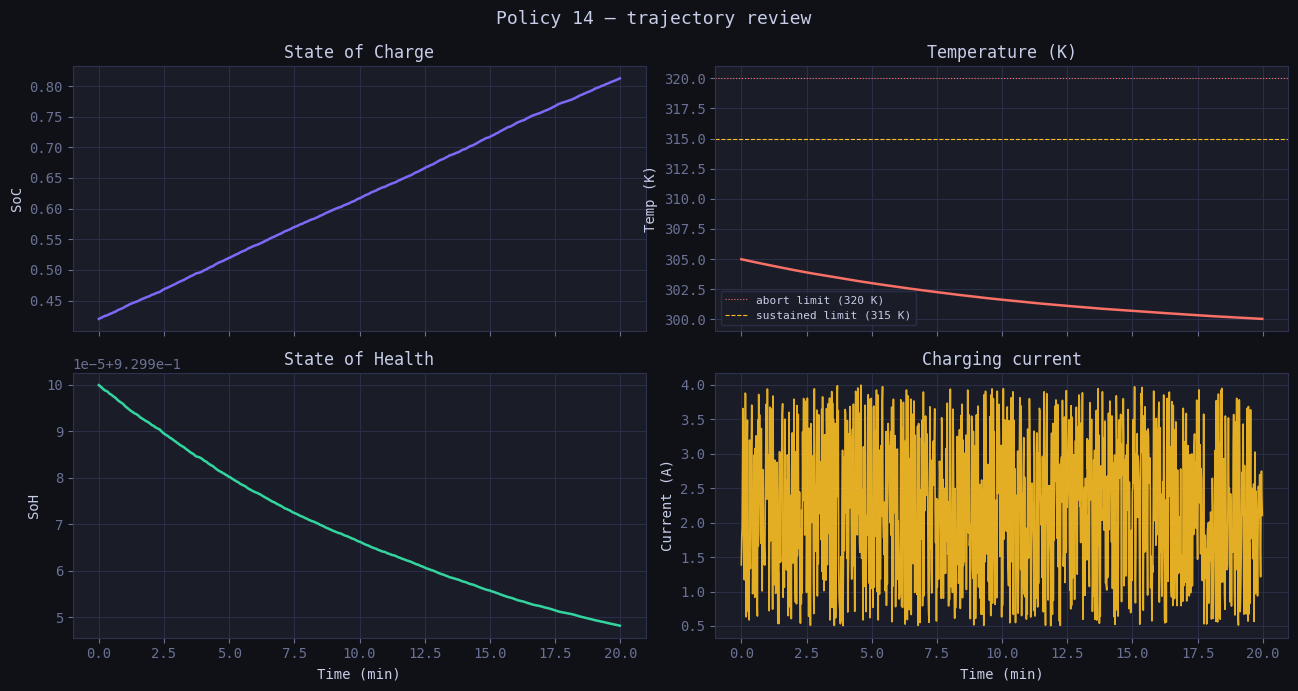

In [5]:
# CELL 4 — Policy trajectory plot (before Kill Agent decision)
t_min = np.arange(len(policy["soc"])) / 60

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

axes[0,0].plot(t_min, policy["soc"],     color=ACCENT, lw=1.8)
axes[0,0].set_title("State of Charge");  axes[0,0].set_ylabel("SoC")

axes[0,1].plot(t_min, policy["temp"],    color=WARM,   lw=1.8)
axes[0,1].axhline(320, color=WARM, lw=0.8, linestyle=":",  label="abort limit (320 K)")
axes[0,1].axhline(315, color=AMBER, lw=0.8, linestyle="--", label="sustained limit (315 K)")
axes[0,1].set_title("Temperature (K)"); axes[0,1].set_ylabel("Temp (K)")
axes[0,1].legend(fontsize=8)

axes[1,0].plot(t_min, policy["soh"],     color=TEAL,   lw=1.8)
axes[1,0].set_title("State of Health");  axes[1,0].set_ylabel("SoH")
axes[1,0].set_xlabel("Time (min)")

axes[1,1].plot(t_min, policy["current"], color=AMBER,  lw=1.2, alpha=0.9)
axes[1,1].set_title("Charging current"); axes[1,1].set_ylabel("Current (A)")
axes[1,1].set_xlabel("Time (min)")

for ax in axes.flat:
    ax.grid(True)

fig.suptitle(f"Policy {selected_policy} — trajectory review", fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# CELL 5 — Compute metrics
def compute_metrics(policy):
    soc  = policy["soc"]
    temp = policy["temp"]
    soh  = policy["soh"]
    return {
        "soc_gain":          soc[-1] - soc[0],
        "peak_temp":         np.max(temp),
        "temp_rise":         np.max(np.diff(temp)),
        "soh_loss":          soh[0] - soh[-1],
        "high_temp_duration": int(np.sum(temp > 315)),
    }

metrics = compute_metrics(policy)

print("\nPolicy metrics:")
for k, v in metrics.items():
    print(f"  {k:>22}: {v:.6f}")


Policy metrics:
                soc_gain: 0.392272
               peak_temp: 304.991508
               temp_rise: -0.000688
                soh_loss: 0.000052
      high_temp_duration: 0.000000


In [7]:
# CELL 6 — Safety thresholds
THRESHOLDS = {
    "peak_temp_limit":   320.0,   # K
    "temp_rise_limit":   5.0,     # K per step (was 2 — too sensitive)
    "soh_loss_limit":    0.001,
    "health_limit":      0.80,
    "high_temp_limit":   5,       # timesteps above 315 K
    "confidence_limit":  0.15,
}

In [8]:
# CELL 7 — Kill Agent with full rule trace
def kill_agent(policy_metrics, battery_state, thresholds):
    """
    Five-rule safety filter with trace logging.
    Returns decision dict + full trace for visualisation.
    """
    checks = []

    def check(name, condition, decision, reason):
        checks.append({
            "rule":     name,
            "value":    condition[0],
            "limit":    condition[1],
            "breached": condition[0] > condition[1],
            "decision": decision if condition[0] > condition[1] else "pass",
            "reason":   reason   if condition[0] > condition[1] else "ok",
        })
        return condition[0] > condition[1]

    # Rule 1 — peak temperature
    if check("Peak temperature",
             (policy_metrics["peak_temp"], thresholds["peak_temp_limit"]),
             "abort", "temperature limit exceeded"):
        return {"decision": "abort", "reason": "temperature limit exceeded"}, checks

    # Rule 2 — rapid heating
    if check("Rapid temp rise",
             (policy_metrics["temp_rise"], thresholds["temp_rise_limit"]),
             "abort", "rapid thermal rise"):
        return {"decision": "abort", "reason": "rapid thermal rise"}, checks

    # Rule 3 — sustained overheating
    if check("Sustained overheating",
             (policy_metrics["high_temp_duration"], thresholds["high_temp_limit"]),
             "override", "sustained high temperature"):
        return {"decision": "override", "reason": "sustained high temperature"}, checks

    # Rule 4 — excess degradation
    if check("SoH loss",
             (policy_metrics["soh_loss"], thresholds["soh_loss_limit"]),
             "override", "excessive degradation"):
        return {"decision": "override", "reason": "excessive degradation"}, checks

    # Rule 5 — weak battery
    if check("Battery health",
             (1 - battery_state["soh"], 1 - thresholds["health_limit"]),
             "override", "battery health low"):
        return {"decision": "override", "reason": "battery health low"}, checks

    # Rule 6 — predictor confidence
    if check("Predictor confidence",
             (battery_state.get("confidence", 0), thresholds["confidence_limit"]),
             "override", "predictor uncertainty too high"):
        return {"decision": "override", "reason": "predictor uncertainty too high"}, checks

    # All clear
    for c in checks:
        c["decision"] = "pass"; c["reason"] = "ok"
    return {"decision": "allow", "reason": "policy safe"}, checks


decision, trace = kill_agent(metrics, battery_state, THRESHOLDS)
print(f"\nKill Agent Decision: {decision['decision'].upper()} — {decision['reason']}")


Kill Agent Decision: ALLOW — policy safe


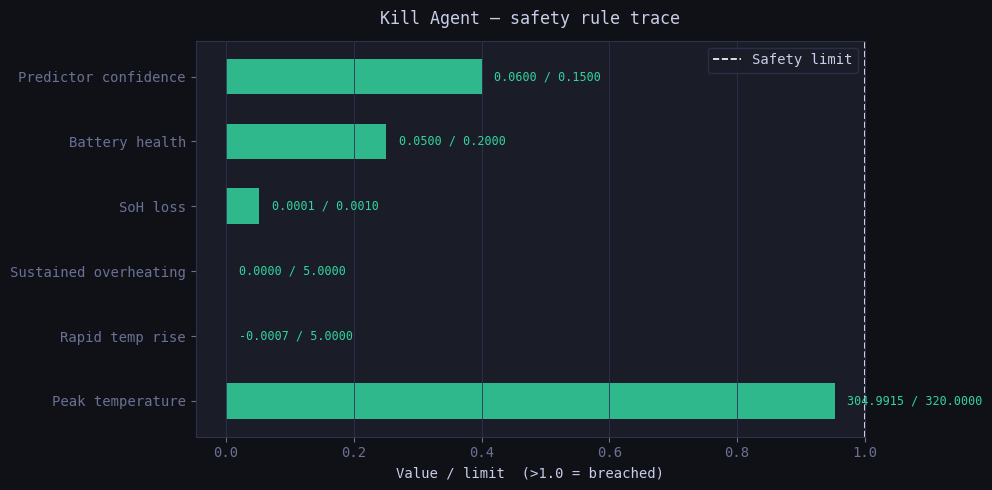

In [9]:
# CELL 8 — Rule trace visualisation
rule_names = [c["rule"]    for c in trace]
values     = [c["value"]   for c in trace]
limits     = [c["limit"]   for c in trace]
breached   = [c["breached"] for c in trace]

# Normalise each value against its limit for a unified bar chart
norm_vals  = [v/l if l != 0 else 0 for v, l in zip(values, limits)]
bar_colors = [WARM if b else TEAL for b in breached]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(rule_names))
bars = ax.barh(x, norm_vals, color=bar_colors, alpha=0.85, height=0.55)
ax.axvline(1.0, color="white", lw=1.2, linestyle="--", label="Safety limit")

for i, (bar, b, val, lim) in enumerate(zip(bars, breached, values, limits)):
    label = f"{val:.4f} / {lim:.4f}"
    ax.text(bar.get_width() + 0.02, i, label,
            va="center", fontsize=8.5,
            color=WARM if b else TEAL)

ax.set_yticks(x)
ax.set_yticklabels(rule_names)
ax.set_xlabel("Value / limit  (>1.0 = breached)")
ax.set_title("Kill Agent — safety rule trace", pad=12)
ax.legend()
ax.grid(True, axis="x")
plt.tight_layout()
plt.show()

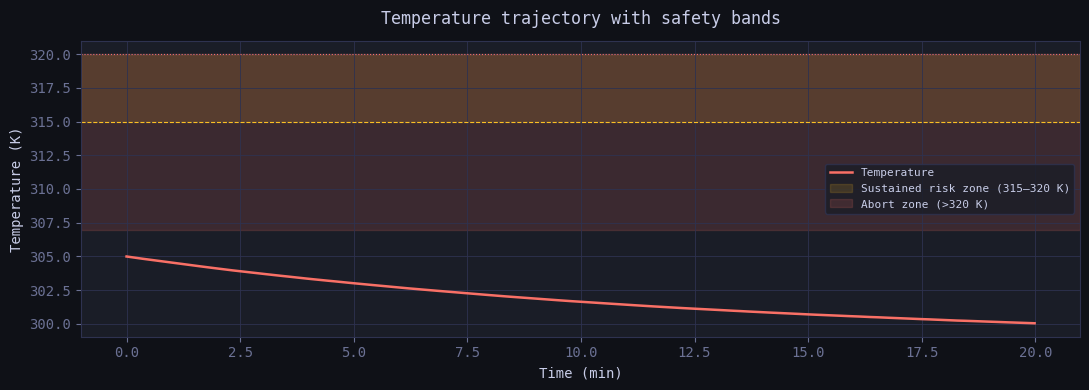

In [10]:
# CELL 9 — Temperature timeline with safety bands
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_min, policy["temp"], color=WARM, lw=1.8, label="Temperature")
ax.axhspan(315, 320, alpha=0.15, color=AMBER,   label="Sustained risk zone (315–320 K)")
ax.axhspan(320, max(policy["temp"]) + 2,
           alpha=0.15, color=WARM, label="Abort zone (>320 K)")
ax.axhline(315, color=AMBER, lw=0.8, linestyle="--")
ax.axhline(320, color=WARM,  lw=0.8, linestyle=":")

# Mark high-temp timesteps
high_mask = policy["temp"] > 315
if high_mask.any():
    ax.scatter(t_min[high_mask], policy["temp"][high_mask],
               color=AMBER, s=12, zorder=4, label=f"Above 315 K ({high_mask.sum()} steps)")

ax.set_xlabel("Time (min)")
ax.set_ylabel("Temperature (K)")
ax.set_title("Temperature trajectory with safety bands", pad=12)
ax.legend(fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.show()

In [11]:
# CELL 10 — Batch evaluation: score all policies
all_decisions = []

for pid in df["solution_id"].unique():
    pol  = extract_policy(df, pid)
    mets = compute_metrics(pol)
    dec, _ = kill_agent(mets, battery_state, THRESHOLDS)
    all_decisions.append({
        "solution_id": pid,
        "decision":    dec["decision"],
        "reason":      dec["reason"],
        "soc_gain":    mets["soc_gain"],
        "peak_temp":   mets["peak_temp"],
        "soh_loss":    mets["soh_loss"],
    })

decisions_df = pd.DataFrame(all_decisions)
counts = decisions_df["decision"].value_counts()
print("\nBatch Kill Agent results:")
print(counts.to_string())


Batch Kill Agent results:
decision
allow    60


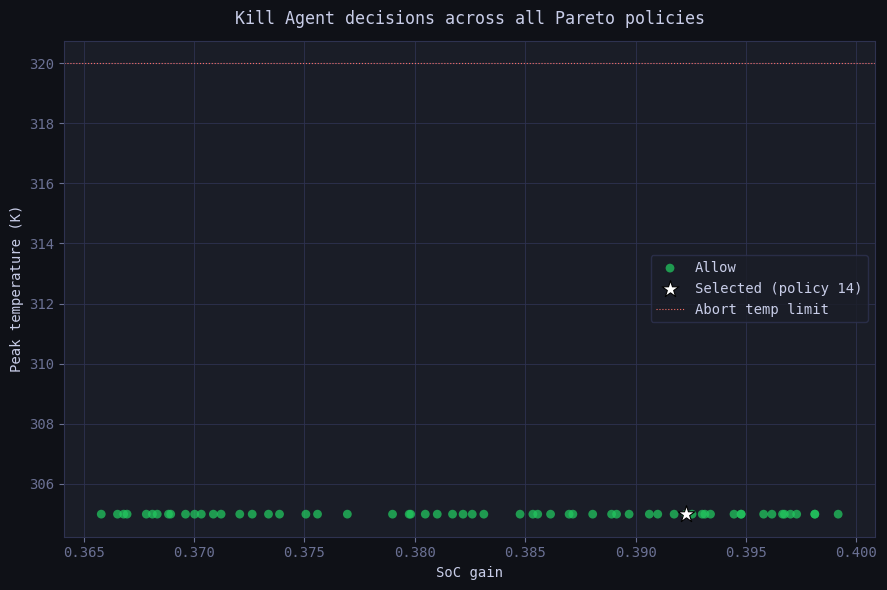

In [12]:
# CELL 11 — Batch decision scatter plot
fig, ax = plt.subplots(figsize=(9, 6))

for dec, grp in decisions_df.groupby("decision"):
    ax.scatter(grp["soc_gain"], grp["peak_temp"],
               color=DECISION_COLORS[dec], s=40, alpha=0.75,
               edgecolors="none", label=dec.capitalize(),
               zorder=3 if dec == "allow" else 2)

# Highlight the selected policy
sel_row = decisions_df[decisions_df["solution_id"] == selected_policy]
if not sel_row.empty:
    ax.scatter(sel_row["soc_gain"], sel_row["peak_temp"],
               color="white", s=160, zorder=6, marker="*",
               edgecolors="black", linewidths=0.8,
               label=f"Selected (policy {selected_policy})")

ax.axhline(THRESHOLDS["peak_temp_limit"], color=WARM, lw=0.8,
           linestyle=":", label="Abort temp limit")
ax.set_xlabel("SoC gain")
ax.set_ylabel("Peak temperature (K)")
ax.set_title("Kill Agent decisions across all Pareto policies", pad=12)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


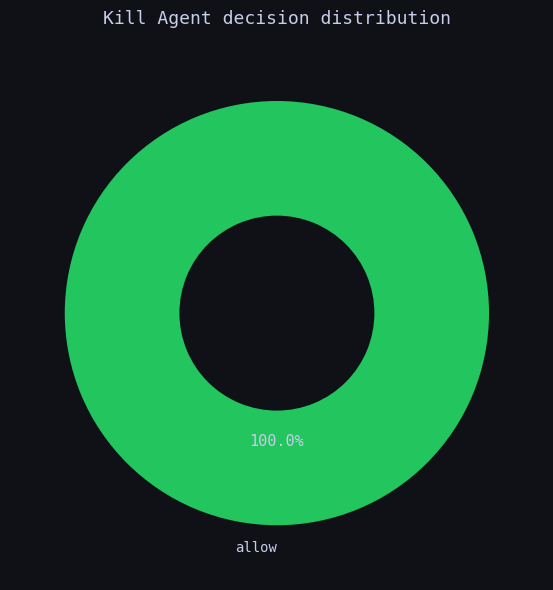

In [13]:
# CELL 12 — Decision donut chart
fig, ax = plt.subplots(figsize=(6, 6))
labels_d = counts.index.tolist()
sizes    = counts.values.tolist()
clrs     = [DECISION_COLORS.get(l, MUTED) for l in labels_d]

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels_d, colors=clrs,
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"width": 0.55, "edgecolor": "#0f1117", "linewidth": 2},
    textprops={"color": "#c8cde8"}
)
for at in autotexts:
    at.set_fontsize(11)

ax.set_title("Kill Agent decision distribution", pad=16, fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
# CELL 13 — Final decision & pipeline output
# Map decision to a real policy_choices reference if available
# (assumes policy_choices dict from Meta-Agent is accessible)
try:
    gentle_policy = decisions_df[decisions_df["decision"] == "allow"]["solution_id"].iloc[0]
except Exception:
    gentle_policy = None

if decision["decision"] == "allow":
    final_policy = selected_policy
    status_color = GREEN
    status_msg   = f"Policy {final_policy} approved — charging may proceed"

elif decision["decision"] == "override":
    safe_candidates = decisions_df[decisions_df["decision"] == "allow"]
    if not safe_candidates.empty:
        # Pick the gentle-most safe policy (min soh_loss)
        final_policy = int(safe_candidates.sort_values("soh_loss").iloc[0]["solution_id"])
    else:
        final_policy = None
    status_color = AMBER
    status_msg   = f"Override — switching to safe policy {final_policy}"

elif decision["decision"] == "abort":
    final_policy = None
    status_color = WARM
    status_msg   = "Charging ABORTED — safety risk"

print("\n" + "="*52)
print(f"  KILL AGENT FINAL OUTPUT")
print("="*52)
print(f"  Decision     : {decision['decision'].upper()}")
print(f"  Reason       : {decision['reason']}")
print(f"  Final policy : {final_policy}")
print(f"  Status       : {status_msg}")
print("="*52)


  KILL AGENT FINAL OUTPUT
  Decision     : ALLOW
  Reason       : policy safe
  Final policy : 14
  Status       : Policy 14 approved — charging may proceed


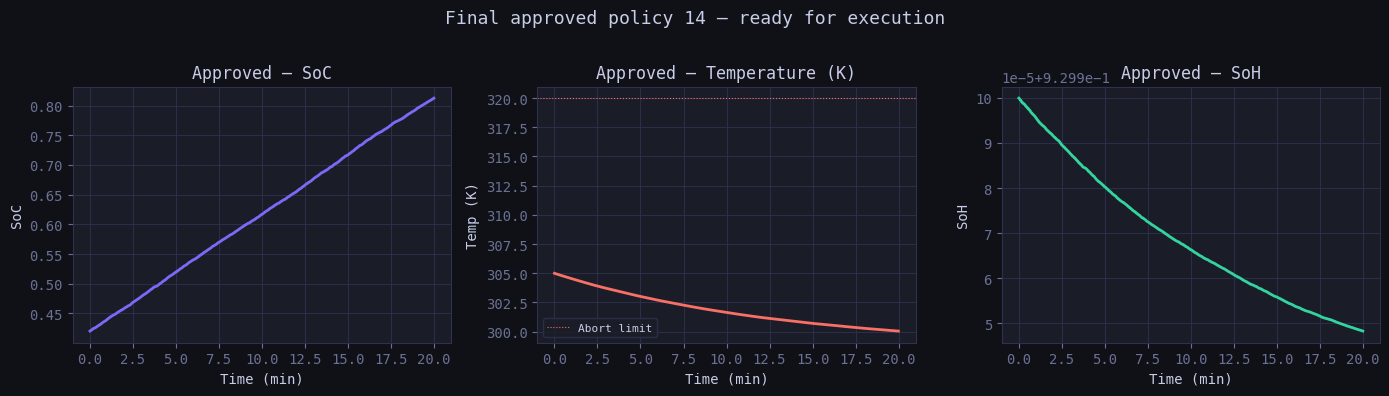

In [15]:
# CELL 14 — Final approved policy trajectory
if final_policy is not None:
    approved = extract_policy(df, final_policy)
    t_ap = np.arange(len(approved["soc"])) / 60

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].plot(t_ap, approved["soc"],  color=ACCENT, lw=2.0)
    axes[0].set_title("Approved — SoC")
    axes[0].set_ylabel("SoC"); axes[0].set_xlabel("Time (min)")

    axes[1].plot(t_ap, approved["temp"], color=WARM, lw=2.0)
    axes[1].axhline(320, color=WARM, lw=0.8, linestyle=":", label="Abort limit")
    axes[1].set_title("Approved — Temperature (K)")
    axes[1].set_ylabel("Temp (K)"); axes[1].set_xlabel("Time (min)")
    axes[1].legend(fontsize=8)

    axes[2].plot(t_ap, approved["soh"],  color=TEAL, lw=2.0)
    axes[2].set_title("Approved — SoH")
    axes[2].set_ylabel("SoH"); axes[2].set_xlabel("Time (min)")

    for ax in axes:
        ax.grid(True)

    fig.suptitle(f"Final approved policy {final_policy} — ready for execution",
                 fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No policy approved — charging halted.")
